# Role Semantic Visualization

Visualize role-schema semantic alignment for Spider, BIRD, and LiveSQLBench datasets using OpenAI embeddings.

**Coverage metric**: Column-level ratio (accessible columns / total columns)

In [1]:
# 1. Setup and imports
import json
import math
import os
import random
import re
import sqlite3
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import PowerNorm
import numpy as np

# Setup project root
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    sys.path.insert(0, str(project_root / 'plot'))

from plot.embedding_utils import cosine_similarity, embed_texts

print(f"Project root: {project_root}")

Project root: /home/feiy/Role-SQL-benchmark


/home/feiy/anaconda3/envs/llm4db/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 2. Configuration
EMBED_MODEL = 'text-embedding-3-small'
EMBED_BACKEND = 'openai'

# Dataset paths
SPIDER_ROLE_FILE = project_root / 'outputs/column_level_role_assignments_spider_20251225.json'
SPIDER_DB_DIR = project_root / 'data/spider/database'

BIRD_ROLE_FILE = project_root / 'outputs/bird_column_level_rbac_assignments_v2_20251230.json'
BIRD_DB_DIR = project_root / 'data/Bird/dev_20251106/dev_databases'

LIVESQL_ROLE_FILE = project_root / 'outputs/livesqlbench_crud/crud_role_assignments_v2_20251230.json'
LIVESQL_DATA_DIR = project_root / 'data/livesqlbench-full-postgresql'

OUTPUT_DIR = project_root / 'plot'

print(f"Embedding model: {EMBED_MODEL} (backend: {EMBED_BACKEND})")
print(f"Spider: {SPIDER_ROLE_FILE.exists()}")
print(f"BIRD: {BIRD_ROLE_FILE.exists()}")
print(f"LiveSQLBench: {LIVESQL_ROLE_FILE.exists()}")

Embedding model: text-embedding-3-small (backend: openai)
Spider: True
BIRD: True
LiveSQLBench: True


In [3]:
# 3. Helper functions - Schema loading

def load_sqlite_schema(db_path: Path) -> dict:
    """Load schema from SQLite database, returns {table: [columns]}."""
    if not db_path.exists():
        return {}
    try:
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%'")
        tables = [row[0] for row in cursor.fetchall()]
        schema = {}
        for table in tables:
            cursor.execute(f'PRAGMA table_info("{table}")')
            columns = [row[1] for row in cursor.fetchall()]
            schema[table.lower()] = columns
        conn.close()
        return schema
    except Exception as e:
        print(f"[WARN] Failed to load schema from {db_path}: {e}")
        return {}

def load_livesql_schema(db_id: str, data_dir: Path) -> dict:
    """Load schema from LiveSQLBench _schema.txt file."""
    schema_file = data_dir / db_id / f"{db_id}_schema.txt"
    if not schema_file.exists():
        return {}
    
    content = schema_file.read_text(encoding='utf-8')
    schema = {}
    
    # Handle quoted CREATE TABLE keywords
    table_pattern = re.compile(
        r'(?:"CREATE"|CREATE)\s+(?:"TABLE"|TABLE)\s+(?:IF\s+NOT\s+EXISTS\s+)?(?:\w+\.)?["\']?(\w+)["\']?\s*\(',
        re.IGNORECASE
    )
    
    for match in table_pattern.finditer(content):
        table_name = match.group(1).lower()
        start = match.end()
        
        # Find matching closing parenthesis
        depth = 1
        end = start
        for i, char in enumerate(content[start:]):
            if char == '(':
                depth += 1
            elif char == ')':
                depth -= 1
                if depth == 0:
                    end = start + i
                    break
        
        col_section = content[start:end]
        columns = []
        
        for line in col_section.split('\n'):
            line = line.strip().strip(',')
            if not line:
                continue
            # Skip constraints
            upper = line.upper()
            if any(kw in upper for kw in ['PRIMARY KEY', 'FOREIGN KEY', 'UNIQUE', 'CHECK', 'CONSTRAINT', 'REFERENCES']):
                continue
            # Extract column name
            col_match = re.match(r'["\']?(\w+)["\']?\s+', line)
            if col_match:
                columns.append(col_match.group(1))
        
        if columns:
            schema[table_name] = columns
    
    return schema

def format_schema_text(schema: dict) -> str:
    """Format schema dict to text for embedding."""
    parts = []
    for table, columns in sorted(schema.items()):
        if columns:
            parts.append(f"{table}: {', '.join(columns)}")
        else:
            parts.append(table)
    return ' '.join(parts)

def count_schema_columns(schema: dict) -> int:
    """Count total columns in schema."""
    return sum(len(cols) for cols in schema.values())

print("✓ Schema loading functions defined")

✓ Schema loading functions defined


In [4]:
# 4. Helper functions - Coverage calculation (column-level)

def count_policy_columns(policy: dict, schema: dict) -> int:
    """Count accessible columns in a column-level policy.
    
    Handles:
    - Explicit column lists: ['col1', 'col2']
    - Wildcard access: ['*'] or '*' means all columns in that table
    
    Logic matches RoleQualityEvaluator.count_policy_columns in quality_metrics.py
    """
    total = 0
    for table, cols in policy.items():
        table_lower = table.lower()
        if cols == ["*"] or cols == "*":
            # Wildcard: count actual columns from schema
            schema_cols = schema.get(table_lower, [])
            total += len(schema_cols) if schema_cols else 1
        elif isinstance(cols, list):
            total += len(cols)
        else:
            total += 1
    return total

def count_crud_columns(role_data: dict, schema: dict) -> int:
    """Count accessible columns with SELECT permission in CRUD-level RBAC.
    
    Logic matches livesqlbench_crud_rbac.ipynb: expand ['*'] to actual column count.
    """
    tables_policy = role_data.get('tables', {})
    total = 0
    for table, perms in tables_policy.items():
        table_lower = table.lower()
        if isinstance(perms, dict):
            select_cols = perms.get('SELECT', [])
            if select_cols:
                # Check for wildcard: ['*'] exactly, not '*' in list
                if select_cols == ['*']:
                    schema_cols = schema.get(table_lower, [])
                    total += len(schema_cols) if schema_cols else 1
                else:
                    total += len(select_cols)
    return total
    return total

print("✓ Coverage calculation functions defined")

✓ Coverage calculation functions defined


In [ ]:
# 5. Plotting functions

# Database name abbreviations for long names
DB_NAME_ABBREV = {
    # BIRD
    'debit_card_specializing': 'debit_card_spec',
    # LiveSQLBench
    'labor_certification_applications': 'labor_cert_app',
    'exchange_traded_funds': 'exchange_funds',
    'cold_chain_pharma_compliance': 'cold_chain_pharma',
}

def abbreviate_db_name(db_id: str) -> str:
    """Return abbreviated name if available, otherwise original."""
    return DB_NAME_ABBREV.get(db_id, db_id)


def prepare_plot_data(records, dbs_per_panel):
    """Prepare data structure for plotting."""
    db_to_entries = defaultdict(list)
    similarities = []
    
    for rec in records:
        db_id = rec['db_id']
        similarity = float(rec['similarity'])
        similarities.append(similarity)
        
        # Column-level coverage ratio
        total_cols = float(rec.get('db_column_count', 0))
        accessible_cols = float(rec.get('num_columns', 0))
        ratio = accessible_cols / total_cols if total_cols > 0 else 0.0
        ratio = min(max(ratio, 0.0), 1.0)
        
        db_to_entries[db_id].append({
            'similarity': similarity,
            'size': 90.0 + ratio * 220.0,
            'is_system_manager': bool(rec.get('is_system_manager', False)),
        })
    
    db_ids = sorted(db_to_entries.keys())
    
    # Chunk into panels
    panels = []
    for i in range(0, len(db_ids), dbs_per_panel):
        panels.append(db_ids[i:i + dbs_per_panel])
    
    panel_heights = [max(1.0, 0.35 * len(chunk) + 0.6) for chunk in panels]
    
    min_sim = min(similarities) if similarities else 0.0
    max_sim = max(similarities) if similarities else 1.0
    if math.isclose(min_sim, max_sim):
        max_sim = min_sim + 1e-6
    
    norm = PowerNorm(gamma=0.55, vmin=min_sim, vmax=max_sim)
    cmap = colormaps['viridis']
    
    # Increase height by 10%
    layout_height = (sum(panel_heights) + 1.6) * 1.1
    
    return {
        'db_to_entries': db_to_entries,
        'panels': panels,
        'panel_heights': panel_heights,
        'min_sim': min_sim,
        'sim_span': max_sim - min_sim,
        'norm': norm,
        'cmap': cmap,
        'layout_height': layout_height,
    }


def render_dataset(container, dataset_name, data, *, show_xlabel=True, title_y=0.97, right_margin=0.85, 
                   scale=1.0):
    """Render a single dataset visualization.
    
    Args:
        scale: Font/marker size multiplier for combined plots (default 1.0)
    """
    random.seed(13)
    
    panels = data['panels']
    panel_heights = data['panel_heights']
    db_to_entries = data['db_to_entries']
    min_sim = data['min_sim']
    sim_span = data['sim_span'] or 1.0
    norm = data['norm']
    cmap = data['cmap']
    
    scalar_map = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    scalar_map.set_array([])
    
    gs = container.add_gridspec(len(panels), 1, height_ratios=panel_heights, hspace=0.18)
    axes = []
    max_label_chars = 1
    
    # Scaled font sizes
    ytick_fontsize = int(19 * scale)
    xtick_fontsize = int(22 * scale)  # X-axis numbers larger
    xlabel_fontsize = int(26 * scale)
    title_fontsize = int(28 * scale)
    cbar_fontsize = int(22 * scale)
    
    # Scaled marker sizes
    marker_scale = scale * scale  # Scale area, not radius
    system_manager_size = 200.0 * marker_scale
    base_marker_multiplier = 3.0 * marker_scale
    
    for panel_idx, db_chunk in enumerate(panels):
        ax = container.add_subplot(gs[panel_idx, 0])
        axes.append(ax)
        
        y_ticks = []
        y_labels = []
        
        for row_idx, db_id in enumerate(db_chunk):
            y = float(row_idx)
            y_ticks.append(y)
            # Use abbreviated name for display
            display_name = abbreviate_db_name(db_id)
            y_labels.append(display_name)
            max_label_chars = max(max_label_chars, len(display_name))
            ax.axhline(y, color='#d0d0d0', linestyle='--', linewidth=0.9, zorder=0)
            
            for entry in db_to_entries[db_id]:
                similarity = entry['similarity']
                base_x = (similarity - min_sim) / sim_span if sim_span else 0.5
                jittered_x = base_x + random.uniform(-0.012, 0.012)
                
                if entry.get('is_system_manager'):
                    ax.scatter(
                        jittered_x, y, s=system_manager_size, c='#d62728', alpha=0.9,
                        edgecolors='#8c1c15', linewidths=0.5 * scale, marker='^', zorder=3
                    )
                else:
                    jittered_y = y + random.uniform(-0.16, 0.16)
                    ax.scatter(
                        jittered_x, jittered_y, s=entry['size'] * base_marker_multiplier,
                        c=[similarity], cmap=cmap, norm=norm,
                        alpha=0.82, edgecolors='#333333', linewidths=0.45 * scale, marker='o'
                    )
        
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_labels, fontsize=ytick_fontsize, weight='bold')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.6, len(db_chunk) - 1 + 0.6)
        
        tick_positions = np.linspace(0.0, 1.0, 5)
        tick_labels = [f"{(min_sim + pos * sim_span):.2f}" for pos in tick_positions]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, fontsize=xtick_fontsize)
        ax.grid(axis='x', linestyle=':', linewidth=0.6, alpha=0.5)
        ax.tick_params(axis='y', labelsize=ytick_fontsize)
        ax.tick_params(axis='x', labelsize=xtick_fontsize)
    
    for ax in axes:
        ax.label_outer()
    
    if show_xlabel:
        axes[-1].set_xlabel('Semantic Similarity', fontsize=xlabel_fontsize, weight='bold')
    else:
        axes[-1].set_xlabel('')
        axes[-1].set_xticklabels([])
    
    # Adjust margins - move title closer to plot
    left_margin = min(0.20, max(0.10, 0.07 + max_label_chars * 0.0075))
    rm = right_margin
    top_margin = 0.90  # Leave room for larger title
    
    container.suptitle(
        f"{dataset_name}: roles vs. schema alignment",
        fontsize=title_fontsize, y=title_y, x=0.5, ha='center', weight='bold'
    )
    container.subplots_adjust(left=left_margin, right=rm, top=top_margin, bottom=0.12, hspace=0.13)
    
    cbar = container.colorbar(scalar_map, ax=axes, fraction=0.04, pad=0.015, location='right')
    cbar.set_label('Role/schema similarity', fontsize=cbar_fontsize, weight='bold')
    cbar.ax.tick_params(labelleft=False, labelright=False, labelsize=xtick_fontsize)


def plot_semantic_roles(records, output_path, title, dbs_per_panel=20):
    """Plot semantic roles for a single dataset."""
    data = prepare_plot_data(records, dbs_per_panel)
    fig = plt.figure(figsize=(16.0, data['layout_height'] + 1.8))
    render_dataset(fig, title, data, show_xlabel=True, title_y=0.97, scale=1.0)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.35)
    plt.show()
    print(f"✓ Saved: {output_path}")
    plt.close(fig)


def plot_roles_multi(dataset_payloads, output_path):
    """Plot multiple datasets horizontally in a single figure."""
    prepared = []
    max_height = 0
    
    for display_name, records, dbs_per_panel in dataset_payloads:
        data = prepare_plot_data(records, dbs_per_panel)
        prepared.append((display_name, data))
        max_height = max(max_height, data['layout_height'])
    
    # Horizontal layout with 35% extra height for better readability in papers
    num_datasets = len(prepared)
    fig_width = 16.0 * num_datasets
    fig_height = (max_height + 2.0) * 1.35  # 35% taller for paper quality
    
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = fig.add_gridspec(1, num_datasets, wspace=0.28)
    
    # Use larger scale (1.5x) for combined plot
    for idx, (display_name, data) in enumerate(prepared):
        subfig = fig.add_subfigure(gs[0, idx])
        render_dataset(subfig, display_name, data, show_xlabel=True, 
                      title_y=0.97, right_margin=0.85, scale=1.5)
    
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.4)
    plt.show()
    print(f"✓ Saved combined plot: {output_path}")
    plt.close(fig)

print("✓ Plotting functions defined")

✓ Plotting functions defined


## 6. Spider Dataset

In [6]:
# 6.1 Load Spider role assignments
with open(SPIDER_ROLE_FILE, 'r') as f:
    spider_data = json.load(f)
spider_assignments = spider_data.get('assignments', {})
print(f"Spider: {len(spider_assignments)} databases")

Spider: 20 databases


In [7]:
# 6.2 Load Spider schemas and compute column counts
spider_schemas = {}
for db_id in spider_assignments.keys():
    db_path = SPIDER_DB_DIR / db_id / f"{db_id}.sqlite"
    schema = load_sqlite_schema(db_path)
    if schema:
        spider_schemas[db_id] = schema
    else:
        print(f"[WARN] Schema not found: {db_id}")

print(f"Loaded {len(spider_schemas)} schemas")

Loaded 20 schemas


In [8]:
# 6.3 Build Spider records with column-level coverage
spider_role_texts = []
spider_schema_texts = []
spider_records = []

for db_id, roles in spider_assignments.items():
    schema = spider_schemas.get(db_id, {})
    total_cols = count_schema_columns(schema)
    schema_text = format_schema_text(schema)
    
    for role_info in roles:
        role_name = role_info.get('role', '')
        description = role_info.get('description', '')
        policy = role_info.get('policy', {})
        
        role_text = f"{role_name} {description}".strip()
        num_cols = count_policy_columns(policy, schema)
        
        spider_role_texts.append(role_text)
        spider_schema_texts.append(schema_text)
        spider_records.append({
            'db_id': db_id,
            'role': role_name,
            'description': description,
            'num_columns': num_cols,
            'db_column_count': total_cols,
            'is_system_manager': role_name.strip().lower() == 'systemmanager',
        })

print(f"Spider records: {len(spider_records)}")
print(f"SystemManagers: {sum(1 for r in spider_records if r['is_system_manager'])}")

Spider records: 93
SystemManagers: 20


In [9]:
# 6.4 Compute Spider embeddings and similarities
unique_role_texts = list(dict.fromkeys(spider_role_texts))
unique_schema_texts = list(dict.fromkeys(spider_schema_texts))

print(f"Computing embeddings for {len(unique_role_texts)} role texts and {len(unique_schema_texts)} schema texts...")

role_embeddings = embed_texts(unique_role_texts, model_name=EMBED_MODEL, backend=EMBED_BACKEND)
schema_embeddings = embed_texts(unique_schema_texts, model_name=EMBED_MODEL, backend=EMBED_BACKEND)

role_emb_dict = dict(zip(unique_role_texts, role_embeddings))
schema_emb_dict = dict(zip(unique_schema_texts, schema_embeddings))

# Compute similarities
for i, rec in enumerate(spider_records):
    role_emb = role_emb_dict[spider_role_texts[i]]
    schema_emb = schema_emb_dict[spider_schema_texts[i]]
    raw_sim = cosine_similarity(role_emb, schema_emb)
    rec['similarity'] = max(0.0, min(1.0, (raw_sim + 1.0) / 2.0))

sims = [r['similarity'] for r in spider_records]
print(f"\nSimilarity stats: Range=[{min(sims):.3f}, {max(sims):.3f}], Mean={sum(sims)/len(sims):.3f}")

ratios = [r['num_columns']/r['db_column_count'] for r in spider_records if r['db_column_count'] > 0]
print(f"Column coverage: Range=[{min(ratios):.3f}, {max(ratios):.3f}], Mean={sum(ratios)/len(ratios):.3f}")

Computing embeddings for 81 role texts and 20 schema texts...
[embedding_utils] Using OpenAI embeddings (text-embedding-3-small) for 81 texts
[embedding_utils] Using OpenAI embeddings (text-embedding-3-small) for 20 texts

Similarity stats: Range=[0.499, 0.791], Mean=0.672
Column coverage: Range=[0.297, 1.000], Mean=0.756


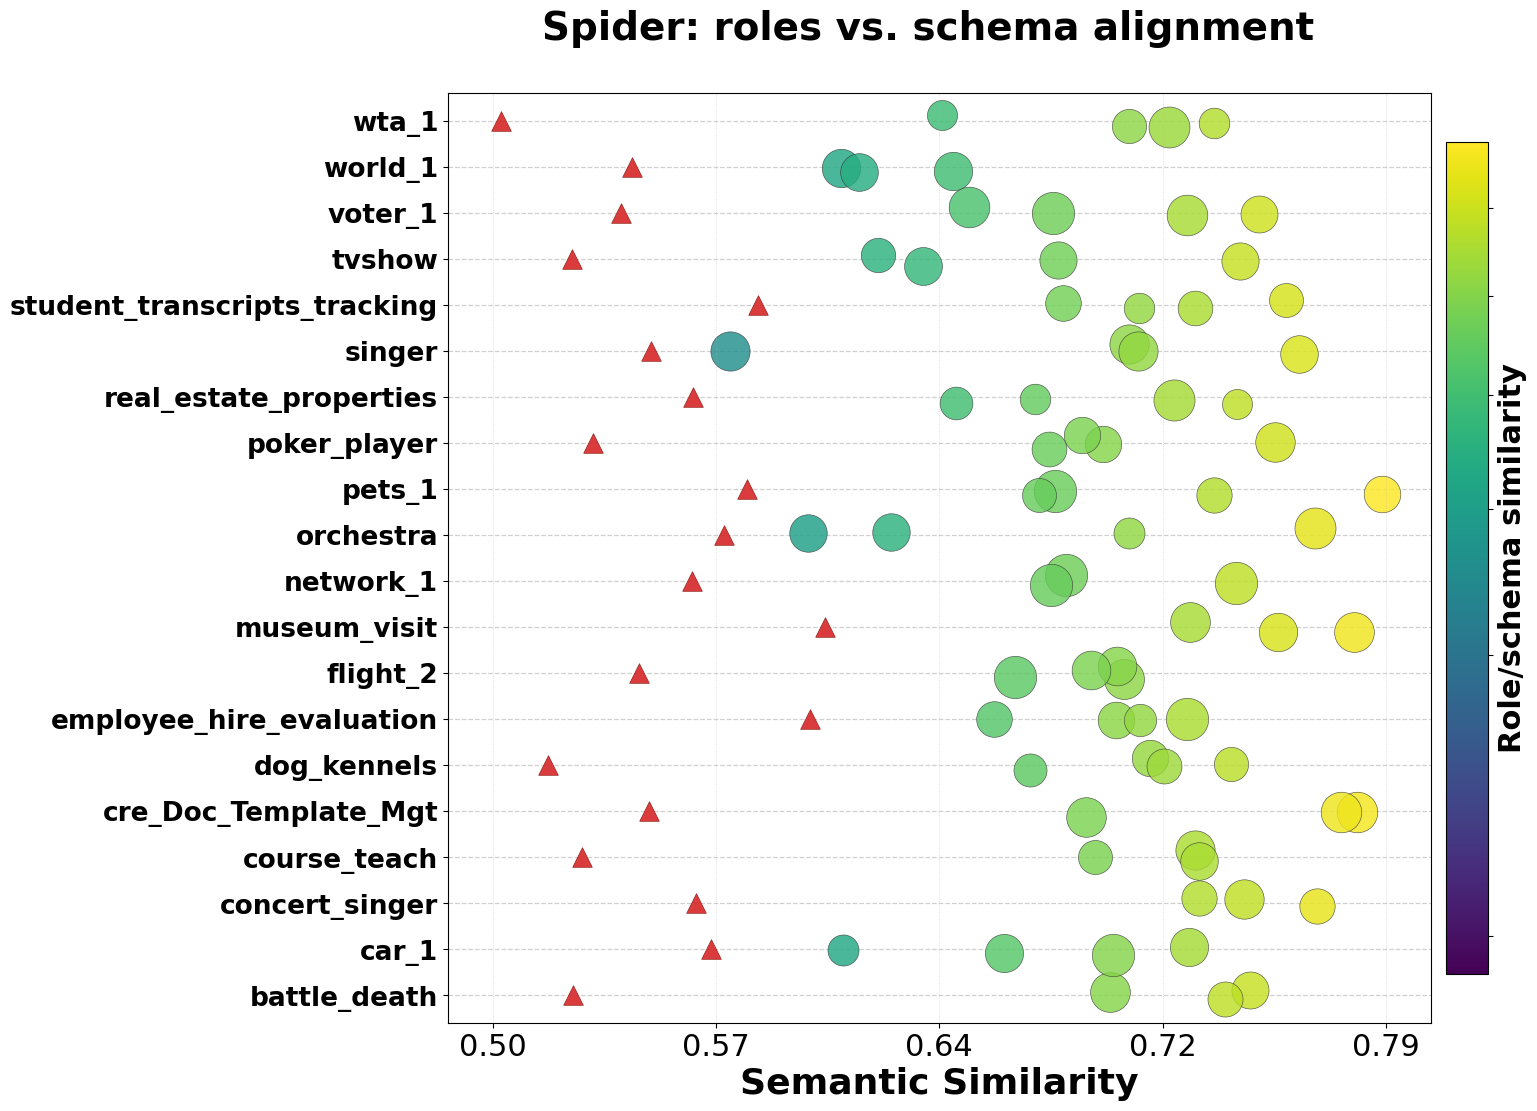

✓ Saved: /home/feiy/Role-SQL-benchmark/plot/spider_column_level_rbac_semantic.pdf


In [10]:
# 6.5 Plot Spider
spider_output = OUTPUT_DIR / 'spider_column_level_rbac_semantic.pdf'
plot_semantic_roles(spider_records, spider_output, 'Spider', dbs_per_panel=20)

## 7. BIRD Dataset

In [11]:
# 7.1 Load BIRD role assignments
with open(BIRD_ROLE_FILE, 'r') as f:
    bird_data = json.load(f)
bird_assignments = bird_data.get('assignments', {})
print(f"BIRD: {len(bird_assignments)} databases")

BIRD: 11 databases


In [12]:
# 7.2 Load BIRD schemas
bird_schemas = {}
for db_id in bird_assignments.keys():
    db_path = BIRD_DB_DIR / db_id / f"{db_id}.sqlite"
    schema = load_sqlite_schema(db_path)
    if schema:
        bird_schemas[db_id] = schema
    else:
        print(f"[WARN] Schema not found: {db_id}")

print(f"Loaded {len(bird_schemas)} schemas")

Loaded 11 schemas


In [13]:
# 7.3 Build BIRD records
bird_role_texts = []
bird_schema_texts = []
bird_records = []

for db_id, roles in bird_assignments.items():
    schema = bird_schemas.get(db_id, {})
    total_cols = count_schema_columns(schema)
    schema_text = format_schema_text(schema)
    
    for role_info in roles:
        role_name = role_info.get('role', '')
        description = role_info.get('description', '')
        policy = role_info.get('policy', {})
        
        role_text = f"{role_name} {description}".strip()
        num_cols = count_policy_columns(policy, schema)
        
        bird_role_texts.append(role_text)
        bird_schema_texts.append(schema_text)
        bird_records.append({
            'db_id': db_id,
            'role': role_name,
            'description': description,
            'num_columns': num_cols,
            'db_column_count': total_cols,
            'is_system_manager': role_name.strip().lower() == 'systemmanager',
        })

print(f"BIRD records: {len(bird_records)}")
print(f"SystemManagers: {sum(1 for r in bird_records if r['is_system_manager'])}")

BIRD records: 53
SystemManagers: 11


In [14]:
# 7.4 Compute BIRD embeddings and similarities
unique_bird_role_texts = list(dict.fromkeys(bird_role_texts))
unique_bird_schema_texts = list(dict.fromkeys(bird_schema_texts))

print(f"Computing embeddings for {len(unique_bird_role_texts)} role texts and {len(unique_bird_schema_texts)} schema texts...")

bird_role_embeddings = embed_texts(unique_bird_role_texts, model_name=EMBED_MODEL, backend=EMBED_BACKEND)
bird_schema_embeddings = embed_texts(unique_bird_schema_texts, model_name=EMBED_MODEL, backend=EMBED_BACKEND)

bird_role_emb_dict = dict(zip(unique_bird_role_texts, bird_role_embeddings))
bird_schema_emb_dict = dict(zip(unique_bird_schema_texts, bird_schema_embeddings))

for i, rec in enumerate(bird_records):
    role_emb = bird_role_emb_dict[bird_role_texts[i]]
    schema_emb = bird_schema_emb_dict[bird_schema_texts[i]]
    raw_sim = cosine_similarity(role_emb, schema_emb)
    rec['similarity'] = max(0.0, min(1.0, (raw_sim + 1.0) / 2.0))

sims = [r['similarity'] for r in bird_records]
print(f"\nSimilarity stats: Range=[{min(sims):.3f}, {max(sims):.3f}], Mean={sum(sims)/len(sims):.3f}")

ratios = [r['num_columns']/r['db_column_count'] for r in bird_records if r['db_column_count'] > 0]
print(f"Column coverage: Range=[{min(ratios):.3f}, {max(ratios):.3f}], Mean={sum(ratios)/len(ratios):.3f}")

Computing embeddings for 47 role texts and 11 schema texts...
[embedding_utils] Using OpenAI embeddings (text-embedding-3-small) for 47 texts
[embedding_utils] Using OpenAI embeddings (text-embedding-3-small) for 11 texts

Similarity stats: Range=[0.521, 0.789], Mean=0.672
Column coverage: Range=[0.155, 1.000], Mean=0.624


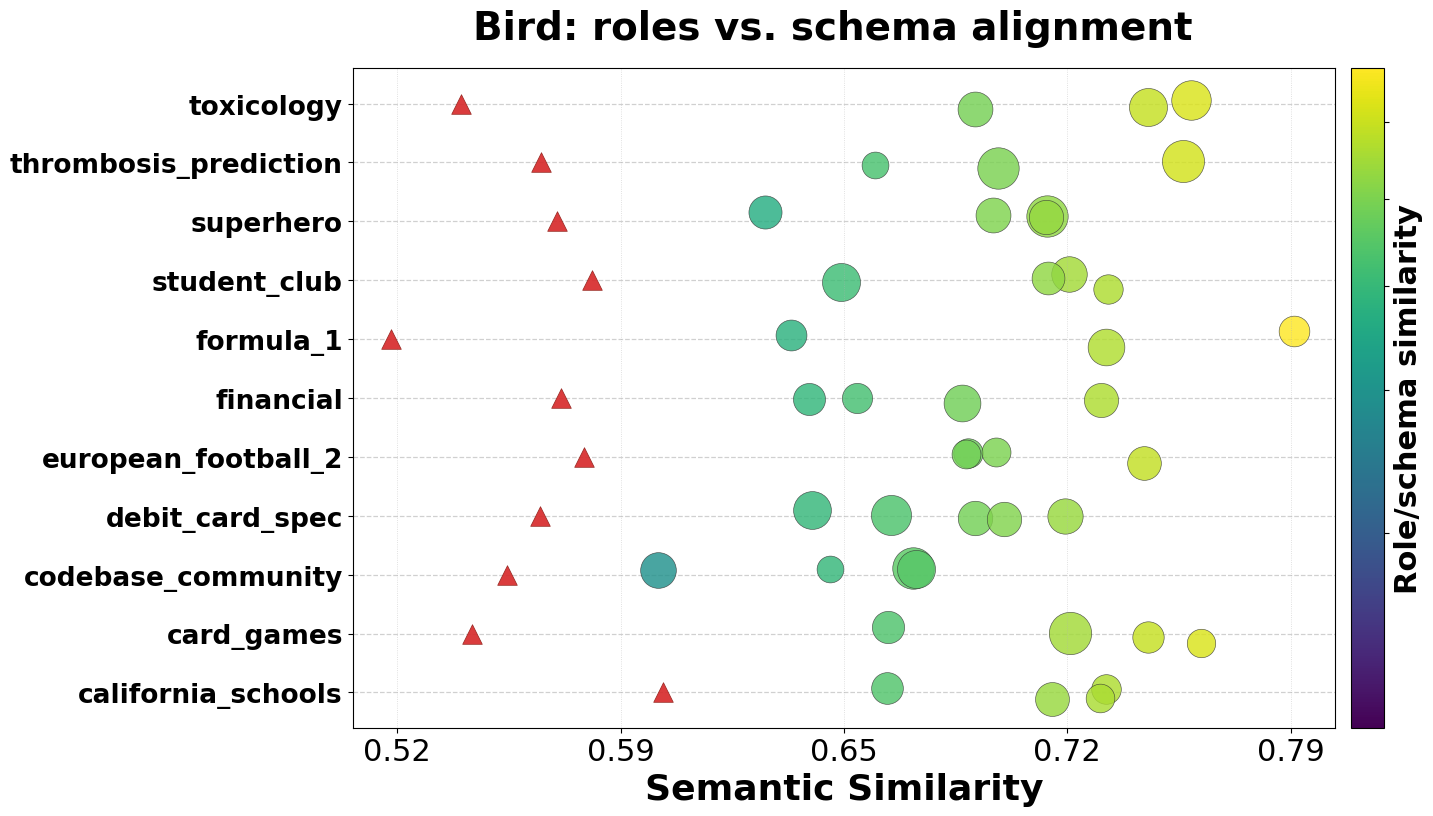

✓ Saved: /home/feiy/Role-SQL-benchmark/plot/bird_column_level_rbac_semantic.pdf


In [15]:
# 7.5 Plot BIRD
bird_output = OUTPUT_DIR / 'bird_column_level_rbac_semantic.pdf'
plot_semantic_roles(bird_records, bird_output, 'Bird', dbs_per_panel=15)

## 8. LiveSQLBench Dataset

In [16]:
# 8.1 Load LiveSQLBench role assignments
with open(LIVESQL_ROLE_FILE, 'r') as f:
    livesql_data = json.load(f)
# Handle both formats: with 'assignments' key or direct dict
livesql_assignments = livesql_data.get('assignments', livesql_data)
print(f"LiveSQLBench: {len(livesql_assignments)} databases")

LiveSQLBench: 22 databases


In [17]:
# 8.2 Load LiveSQLBench schemas
livesql_schemas = {}
for db_id in livesql_assignments.keys():
    schema = load_livesql_schema(db_id, LIVESQL_DATA_DIR)
    if schema:
        livesql_schemas[db_id] = schema
    else:
        print(f"[WARN] Schema not found: {db_id}")

print(f"Loaded {len(livesql_schemas)} schemas")

Loaded 22 schemas


In [18]:
# 8.3 Build LiveSQLBench records
livesql_role_texts = []
livesql_schema_texts = []
livesql_records = []

for db_id, roles in livesql_assignments.items():
    schema = livesql_schemas.get(db_id, {})
    if not schema:
        continue
    
    total_cols = count_schema_columns(schema)
    schema_text = format_schema_text(schema)
    
    for role_info in roles:
        role_name = role_info.get('role', '')
        description = role_info.get('description', '')
        
        role_text = f"{role_name} {description}".strip()
        num_cols = count_crud_columns(role_info, schema)
        
        livesql_role_texts.append(role_text)
        livesql_schema_texts.append(schema_text)
        livesql_records.append({
            'db_id': db_id,
            'role': role_name,
            'description': description,
            'num_columns': num_cols,
            'db_column_count': total_cols,
            'is_system_manager': role_name.strip().lower() == 'systemmanager',
        })

print(f"LiveSQLBench records: {len(livesql_records)}")
print(f"SystemManagers: {sum(1 for r in livesql_records if r['is_system_manager'])}")

LiveSQLBench records: 119
SystemManagers: 22


In [19]:
# 8.4 Compute LiveSQLBench embeddings and similarities
unique_livesql_role_texts = list(dict.fromkeys(livesql_role_texts))
unique_livesql_schema_texts = list(dict.fromkeys(livesql_schema_texts))

print(f"Computing embeddings for {len(unique_livesql_role_texts)} role texts and {len(unique_livesql_schema_texts)} schema texts...")

livesql_role_embeddings = embed_texts(unique_livesql_role_texts, model_name=EMBED_MODEL, backend=EMBED_BACKEND)
livesql_schema_embeddings = embed_texts(unique_livesql_schema_texts, model_name=EMBED_MODEL, backend=EMBED_BACKEND)

livesql_role_emb_dict = dict(zip(unique_livesql_role_texts, livesql_role_embeddings))
livesql_schema_emb_dict = dict(zip(unique_livesql_schema_texts, livesql_schema_embeddings))

for i, rec in enumerate(livesql_records):
    role_emb = livesql_role_emb_dict[livesql_role_texts[i]]
    schema_emb = livesql_schema_emb_dict[livesql_schema_texts[i]]
    raw_sim = cosine_similarity(role_emb, schema_emb)
    rec['similarity'] = max(0.0, min(1.0, (raw_sim + 1.0) / 2.0))

sims = [r['similarity'] for r in livesql_records]
print(f"\nSimilarity stats: Range=[{min(sims):.3f}, {max(sims):.3f}], Mean={sum(sims)/len(sims):.3f}")

ratios = [r['num_columns']/r['db_column_count'] for r in livesql_records if r['db_column_count'] > 0]
print(f"Column coverage: Range=[{min(ratios):.3f}, {max(ratios):.3f}], Mean={sum(ratios)/len(ratios):.3f}")

Computing embeddings for 104 role texts and 22 schema texts...
[embedding_utils] Using OpenAI embeddings (text-embedding-3-small) for 104 texts
[embedding_utils] Using OpenAI embeddings (text-embedding-3-small) for 22 texts

Similarity stats: Range=[0.553, 0.811], Mean=0.694
Column coverage: Range=[0.088, 1.000], Mean=0.532


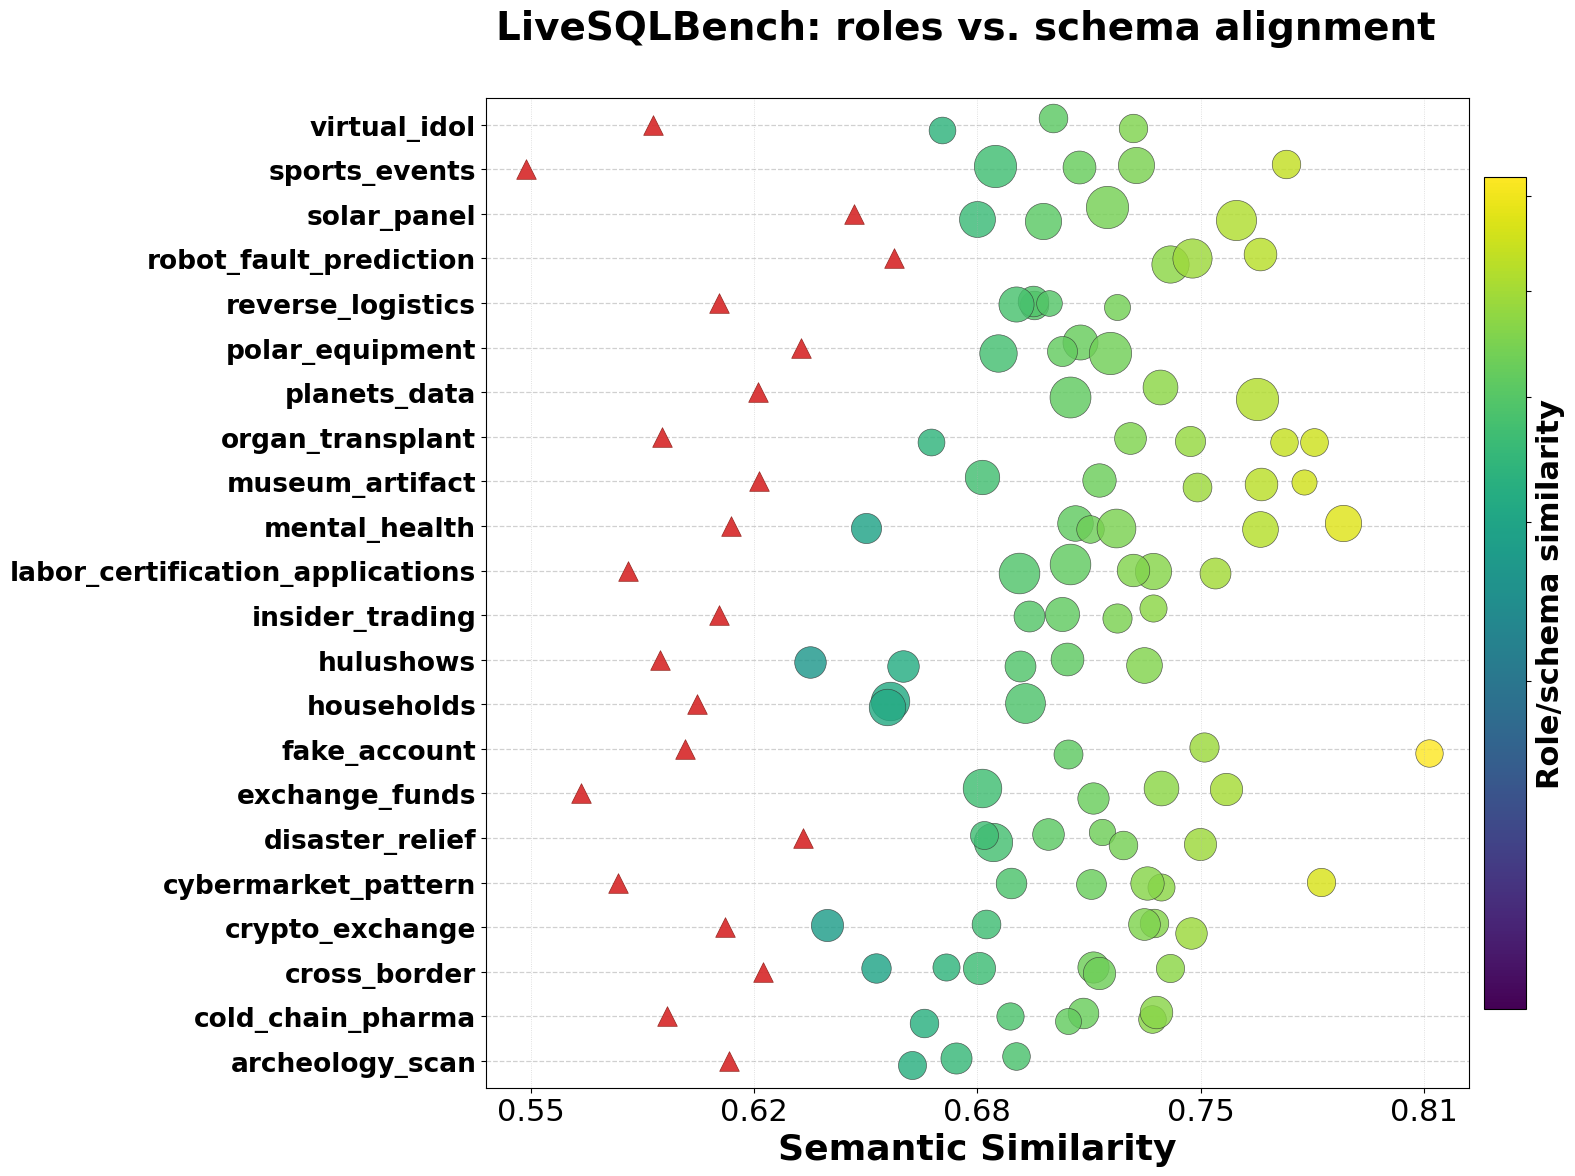

✓ Saved: /home/feiy/Role-SQL-benchmark/plot/livesqlbench_crud_rbac_semantic.pdf


In [20]:
# 8.5 Plot LiveSQLBench
livesql_output = OUTPUT_DIR / 'livesqlbench_crud_rbac_semantic.pdf'
plot_semantic_roles(livesql_records, livesql_output, 'LiveSQLBench', dbs_per_panel=22)

## 9. Summary

In [21]:
# 9.1 Summary statistics
datasets = [
    ('Spider', spider_records),
    ('BIRD', bird_records),
    ('LiveSQLBench', livesql_records),
]

print("=" * 60)
print("Dataset Summary (Column-Level Coverage)")
print("=" * 60)

for name, records in datasets:
    db_ids = set(r['db_id'] for r in records)
    sims = [r['similarity'] for r in records]
    ratios = [r['num_columns']/r['db_column_count'] for r in records if r['db_column_count'] > 0]
    sm_count = sum(1 for r in records if r['is_system_manager'])
    
    print(f"\n{name}:")
    print(f"  Databases: {len(db_ids)}")
    print(f"  Total roles: {len(records)}")
    print(f"  SystemManagers: {sm_count}")
    print(f"  Similarity: [{min(sims):.3f}, {max(sims):.3f}], mean={sum(sims)/len(sims):.3f}")
    print(f"  Column coverage: [{min(ratios):.3f}, {max(ratios):.3f}], mean={sum(ratios)/len(ratios):.3f}")

Dataset Summary (Column-Level Coverage)

Spider:
  Databases: 20
  Total roles: 93
  SystemManagers: 20
  Similarity: [0.499, 0.791], mean=0.672
  Column coverage: [0.297, 1.000], mean=0.756

BIRD:
  Databases: 11
  Total roles: 53
  SystemManagers: 11
  Similarity: [0.521, 0.789], mean=0.672
  Column coverage: [0.155, 1.000], mean=0.624

LiveSQLBench:
  Databases: 22
  Total roles: 119
  SystemManagers: 22
  Similarity: [0.553, 0.811], mean=0.694
  Column coverage: [0.088, 1.000], mean=0.532


## 10. Combined Visualization

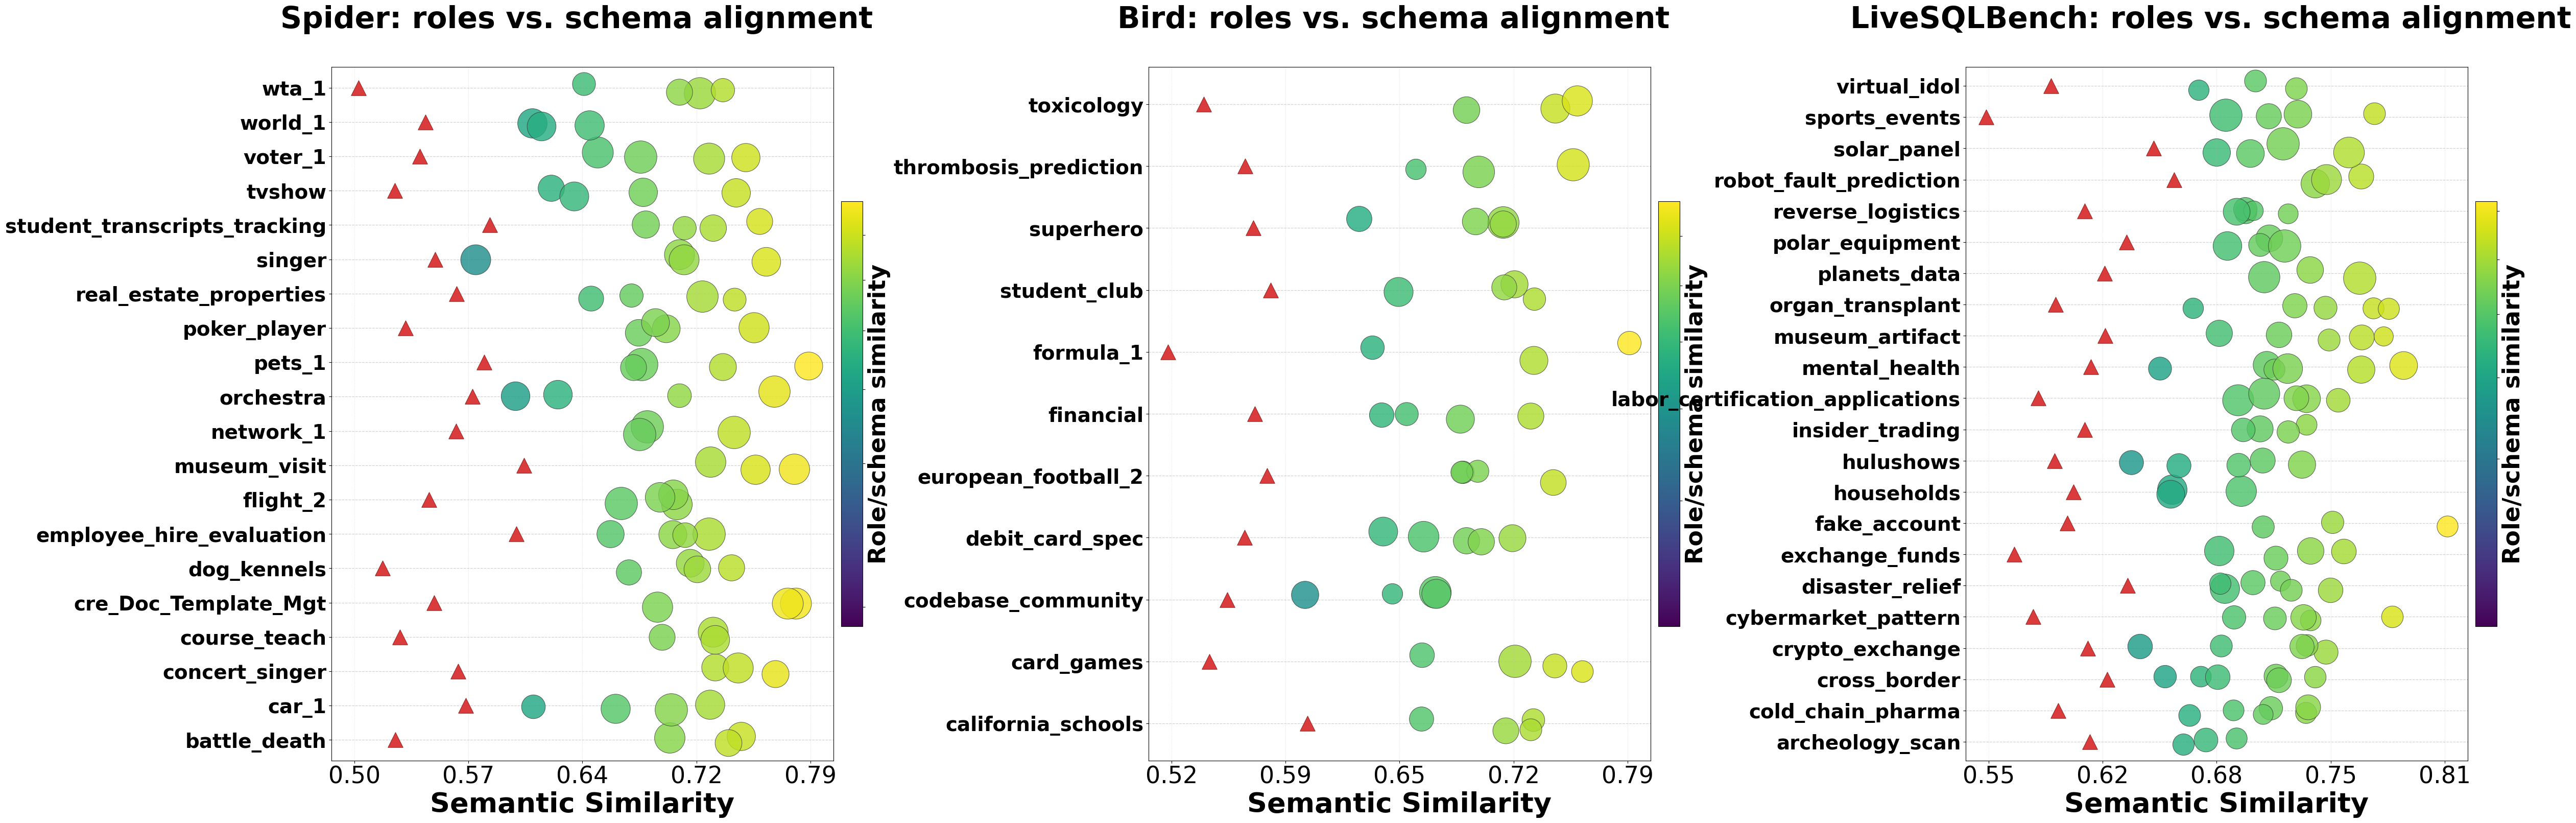

✓ Saved combined plot: /home/feiy/Role-SQL-benchmark/plot/all_datasets_rbac_semantic.pdf


In [22]:
# 10.1 Generate combined horizontal plot
combined_output = OUTPUT_DIR / 'all_datasets_rbac_semantic.pdf'

combined_payloads = [
    ('Spider', spider_records, 20),
    ('Bird', bird_records, 15),
    ('LiveSQLBench', livesql_records, 22),
]

plot_roles_multi(combined_payloads, combined_output)